# Python Programming Quiz: Executed Review

University of Washington | Computational Neuroscience | September 14, 2026

Worked examples for the 14 shared practice questions. Option numbers match the screenshots. Code uses descriptive variable names; [the Markdown answer key](python_programming_quiz.md) preserves the original notation.

**Notebook guide:** Cell 2 loads the libraries. Cells 3 through 16 cover Questions 1 through 14. Cell 18 checks completion and prints the answer key.

Run the setup cell first, then the question cells in order. Saved outputs include array values, expected error messages, intermediate matrices, and the plot. Random examples are seeded. The pickle example creates and removes its own trusted data. Question 14 skips its breakpoint unless you deliberately enable it.

**Executed environment:** Python 3.11.1, NumPy 2.4.6, Matplotlib 3.11.2. Select a Python kernel with NumPy, Matplotlib, and ipykernel when rerunning. Successful execution verifies these examples, not course submission, a grade, or independent mastery.

In [1]:
import sys
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import display

np.set_printoptions(precision=4, suppress=True)
verified_questions = set()
print('Python:', sys.version.split()[0])
print('NumPy:', np.__version__)
print('Matplotlib:', matplotlib.__version__)
print('Ready: imports succeeded.')

Python: 3.11.1
NumPy: 2.4.6
Matplotlib: 3.11.2
Ready: imports succeeded.


In [2]:
print('Question 1 | Correct option: 2')
print('Each nested list is a row: four rows, three columns.')
matrix = np.array([[1, 2, 3], [2, 3, 4], [3, 4, 5], [4, 5, 6]])
display(matrix)
print('Shape:', matrix.shape)
assert matrix.shape == (4, 3)
np.testing.assert_array_equal(matrix, [[1, 2, 3], [2, 3, 4], [3, 4, 5], [4, 5, 6]])
verified_questions.add(1)

Question 1 | Correct option: 2
Each nested list is a row: four rows, three columns.


array([[1, 2, 3],
       [2, 3, 4],
       [3, 4, 5],
       [4, 5, 6]])

Shape: (4, 3)


In [3]:
print('Question 2 | Correct option: 1')
matrix = np.array([[1, 2, 3, 4], [2, 3, 4, 5], [3, 4, 5, 6]])
selected = matrix[[0, 2], 1:]
print('Rows 0 and 2; columns from index 1 onward:')
display(selected)
np.testing.assert_array_equal(selected, [[2, 3, 4], [4, 5, 6]])
print('Using 2: instead gives only two columns:')
display(matrix[[0, 2], 2:])
try:
    matrix[[1, 3], 2:]
except IndexError as error:
    print('Expected IndexError for row 3:', error)
else:
    raise AssertionError('Row 3 must be out of bounds.')
verified_questions.add(2)

Question 2 | Correct option: 1
Rows 0 and 2; columns from index 1 onward:


array([[2, 3, 4],
       [4, 5, 6]])

Using 2: instead gives only two columns:


array([[3, 4],
       [5, 6]])

Expected IndexError for row 3: index 3 is out of bounds for axis 0 with size 3


In [4]:
print('Question 3 | Correct option: 3')
namespace = {}
try:
    exec('array = np.array([1, 2, 3])', namespace)
except NameError as error:
    print('Before importing:', type(error).__name__, '-', error)
else:
    raise AssertionError('A fresh namespace should not define np.')
exec('import numpy as np\narray = np.array([1, 2, 3])', namespace)
print('After import numpy as np:')
display(namespace['array'])
np.testing.assert_array_equal(namespace['array'], [1, 2, 3])
print('The import must run before np is used, not at the end of the script.')
verified_questions.add(3)

Question 3 | Correct option: 3
Before importing: NameError - name 'np' is not defined
After import numpy as np:


array([1, 2, 3])

The import must run before np is used, not at the end of the script.


In [5]:
print('Question 4 | Correct options: 2, 3, 5, 6, 7')
values = np.array([1, 2, 3, 4])
options = [
    (1, 'np.ones(5, 5)', lambda: np.ones(5, 5)),
    (2, 'np.ones(5,)', lambda: np.ones(5,)),
    (3, 'values[4:]', lambda: values[4:]),
    (4, 'values[4]', lambda: values[4]),
    (5, 'values[:5]', lambda: values[:5]),
    (6, 'np.ones((5, 5))', lambda: np.ones((5, 5))),
    (7, 'values[:2]', lambda: values[:2]),
]
successful_options = []
for number, expression, operation in options:
    try:
        result = operation()
    except (TypeError, IndexError) as error:
        print(f'Option {number}: {expression} -> {type(error).__name__}: {error}')
    else:
        successful_options.append(number)
        print(f'Option {number}: {expression} -> shape {result.shape}, values {result.tolist()}')
assert successful_options == [2, 3, 5, 6, 7]
assert values[4:].size == 0
np.testing.assert_array_equal(values[:5], values)
print('\nSlices can be empty or clipped; direct out-of-range indexing fails.')
print('A multi-dimensional shape is one tuple argument, not two scalar arguments.')
verified_questions.add(4)

Question 4 | Correct options: 2, 3, 5, 6, 7
Option 1: np.ones(5, 5) -> TypeError: Cannot interpret '5' as a data type
Option 2: np.ones(5,) -> shape (5,), values [1.0, 1.0, 1.0, 1.0, 1.0]
Option 3: values[4:] -> shape (0,), values []
Option 4: values[4] -> IndexError: index 4 is out of bounds for axis 0 with size 4
Option 5: values[:5] -> shape (4,), values [1, 2, 3, 4]
Option 6: np.ones((5, 5)) -> shape (5, 5), values [[1.0, 1.0, 1.0, 1.0, 1.0], [1.0, 1.0, 1.0, 1.0, 1.0], [1.0, 1.0, 1.0, 1.0, 1.0], [1.0, 1.0, 1.0, 1.0, 1.0], [1.0, 1.0, 1.0, 1.0, 1.0]]
Option 7: values[:2] -> shape (2,), values [1, 2]

Slices can be empty or clipped; direct out-of-range indexing fails.
A multi-dimensional shape is one tuple argument, not two scalar arguments.


In [6]:
print('Question 5 | Correct option: 2')
np.random.seed(42)
random_values = np.random.rand(100)
print('First 10 samples:', random_values[:10])
print('Shape:', random_values.shape)
print(f'Minimum: {random_values.min():.4f}; maximum: {random_values.max():.4f}')
assert random_values.shape == (100,)
assert np.all((random_values >= 0) & (random_values < 1))
print('All 100 samples are in [0, 1). A seed makes this example reproducible.')
print('np.random is a module; np.random.rand is the callable used by the quiz.')
modern_values = np.random.default_rng(42).random(100)
assert modern_values.shape == (100,)
assert np.all((modern_values >= 0) & (modern_values < 1))
print('Modern equivalent: np.random.default_rng(42).random(100).')
print('The two generators need not produce the same sequence for the same seed.')
verified_questions.add(5)

Question 5 | Correct option: 2
First 10 samples: [0.3745 0.9507 0.732  0.5987 0.156  0.156  0.0581 0.8662 0.6011 0.7081]
Shape: (100,)
Minimum: 0.0055; maximum: 0.9869
All 100 samples are in [0, 1). A seed makes this example reproducible.
np.random is a module; np.random.rand is the callable used by the quiz.
Modern equivalent: np.random.default_rng(42).random(100).
The two generators need not produce the same sequence for the same seed.


In [7]:
print('Question 6 | Correct option: 4')
original = np.random.default_rng(42).random(100)
updated = original.copy()
updated[updated > 0.5] = 1
print('Before, first 10:', original[:10])
print('After, first 10: ', updated[:10])
print('Number changed:', np.count_nonzero(original > 0.5))
assert np.all(updated[original > 0.5] == 1)
np.testing.assert_array_equal(updated[original <= 0.5], original[original <= 0.5])
boundary_values = np.array([0.2, 0.5, 0.8])
boundary_values[boundary_values > 0.5] = 1
np.testing.assert_array_equal(boundary_values, [0.2, 0.5, 1.0])
print('Boundary example [0.2, 0.5, 0.8] becomes:', boundary_values)
print('Exactly 0.5 stays unchanged: the condition is >, not >=.')
verified_questions.add(6)

Question 6 | Correct option: 4
Before, first 10: [0.774  0.4389 0.8586 0.6974 0.0942 0.9756 0.7611 0.7861 0.1281 0.4504]
After, first 10:  [1.     0.4389 1.     1.     0.0942 1.     1.     1.     0.1281 0.4504]
Number changed: 47
Boundary example [0.2, 0.5, 0.8] becomes: [0.2 0.5 1. ]
Exactly 0.5 stays unchanged: the condition is >, not >=.


In [8]:
print('Question 7 | Correct option: 4')
values = np.array([0, 4, 1, 6, 7, 0, 8])
mask = values > 1
first_indices = (values > 1).nonzero()[0][:3]
print('Original values:     ', values)
print('Boolean mask:        ', mask)
print('nonzero() tuple:     ', mask.nonzero())
print('First three indices: ', first_indices)
print('First three values:  ', values[values > 1][:3])
np.testing.assert_array_equal(first_indices, [1, 3, 4])
np.testing.assert_array_equal(values[first_indices], [4, 6, 7])
fewer_matches = np.array([0, 2, 0])
np.testing.assert_array_equal((fewer_matches > 1).nonzero()[0][:3], [1])
print('With only one match, [:3] returns the available index without an error.')
verified_questions.add(7)

Question 7 | Correct option: 4
Original values:      [0 4 1 6 7 0 8]
Boolean mask:         [False  True False  True  True False  True]
nonzero() tuple:      (array([1, 3, 4, 6]),)
First three indices:  [1 3 4]
First three values:   [4 6 7]
With only one match, [:3] returns the available index without an error.


In [9]:
print('Question 8 | Correct option: 1')
import pickle
from pathlib import Path
from tempfile import TemporaryDirectory

trusted_dictionary = {'a': 3, 'c': 9, 'b': 5}
with TemporaryDirectory(prefix='uw_python_quiz_') as temporary_directory:
    dataset_path = Path(temporary_directory) / 'data.pickle'
    with dataset_path.open('wb') as data_file:
        pickle.dump(trusted_dictionary, data_file)
    with dataset_path.open('rb') as data_file:
        data = pickle.load(data_file)
    print('Loaded object:', data)
    print('Loaded type:', type(data).__name__)
    assert isinstance(data, dict)
    assert data == trusted_dictionary
assert not dataset_path.exists()
print('PASS: temporary file removed automatically.')
print('rb means read binary; pickle.load reconstructs the saved object.')
print('Only unpickle trusted data. This example creates its own dictionary, not an external download.')
verified_questions.add(8)

Question 8 | Correct option: 1
Loaded object: {'a': 3, 'c': 9, 'b': 5}
Loaded type: dict
PASS: temporary file removed automatically.
rb means read binary; pickle.load reconstructs the saved object.
Only unpickle trusted data. This example creates its own dictionary, not an external download.


In [10]:
print('Question 9 | Correct option: 1')
data = {'a': 3, 'c': 9, 'b': 5}
print('Before:', data)
data['b'] = 100
print('After: ', data)
assert data == {'a': 3, 'c': 9, 'b': 100}
print('String dictionary keys use square brackets and quotes, not attribute syntax.')
verified_questions.add(9)

Question 9 | Correct option: 1
Before: {'a': 3, 'c': 9, 'b': 5}
After:  {'a': 3, 'c': 9, 'b': 100}
String dictionary keys use square brackets and quotes, not attribute syntax.


Question 10 | Correct option: 3
Samples: 100; first x: 0.00; last x: 4.95
Starts at zero; amplitude 1; oscillations become more frequent.
np.arange excludes 5 here, unlike the MATLAB quiz range.


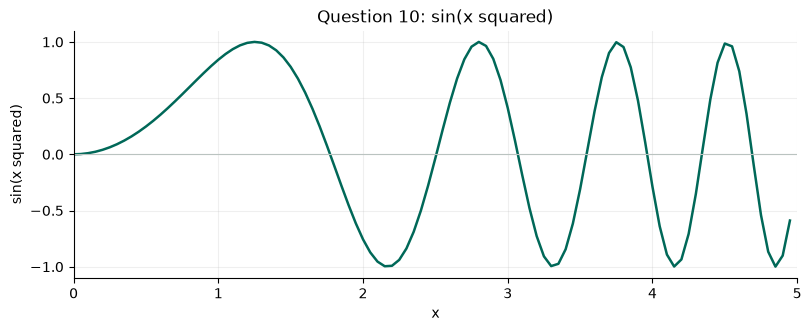

In [11]:
print('Question 10 | Correct option: 3')
samples = np.arange(0, 5, step=0.05)
signal = np.sin(samples ** 2)
assert samples.size == 100
assert np.isclose(samples[-1], 4.95)
assert signal[0] == 0
assert np.all(np.abs(signal) <= 1)
print(f'Samples: {samples.size}; first x: {samples[0]:.2f}; last x: {samples[-1]:.2f}')
print('Starts at zero; amplitude 1; oscillations become more frequent.')
print('np.arange excludes 5 here, unlike the MATLAB quiz range.')
figure, axes = plt.subplots(figsize=(8, 3.2), constrained_layout=True)
axes.plot(samples, signal, color='#006858', linewidth=1.8)
axes.axhline(0, color='#bac3c0', linewidth=0.8)
axes.set(xlabel='x', ylabel='sin(x squared)', title='Question 10: sin(x squared)', xlim=(0, 5), ylim=(-1.1, 1.1))
axes.grid(alpha=0.2)
axes.spines[['top', 'right']].set_visible(False)
plt.show()
verified_questions.add(10)

In [12]:
print('Question 11 | Correct option: 2')
values = np.array([1, 2, 3, 4, 5])
cubed = values ** 3
print('Original:                 ', values)
print('Cubed with ** 3:          ', cubed)
print('Multiplied by 3 instead:  ', values * 3)
print('Bitwise XOR with 3:       ', values ^ 3)
np.testing.assert_array_equal(cubed, [1, 8, 27, 64, 125])
print('Python exponentiation is **, not ^. MATLAB syntax .^ is invalid Python.')
verified_questions.add(11)

Question 11 | Correct option: 2
Original:                  [1 2 3 4 5]
Cubed with ** 3:           [  1   8  27  64 125]
Multiplied by 3 instead:   [ 3  6  9 12 15]
Bitwise XOR with 3:        [2 1 0 7 6]
Python exponentiation is **, not ^. MATLAB syntax .^ is invalid Python.


In [13]:
print('Question 12 | Correct option: 2')
matrix = np.array([[1, 2, 3], [2, 3, 4]])
print('Initial:')
display(matrix.copy())
matrix *= 5
print('After *= 5:')
display(matrix.copy())
np.testing.assert_array_equal(matrix, [[5, 10, 15], [10, 15, 20]])
matrix -= 1
print('After -= 1:')
display(matrix.copy())
np.testing.assert_array_equal(matrix, [[4, 9, 14], [9, 14, 19]])
matrix[matrix > 10] = 0
print('After replacing values > 10:')
display(matrix.copy())
np.testing.assert_array_equal(matrix, [[4, 9, 0], [9, 0, 0]])
matrix = matrix.T
print('Final transpose:')
display(matrix)
np.testing.assert_array_equal(matrix, [[4, 9], [9, 0], [0, 0]])
assert matrix.shape == (3, 2)
print('Final shape:', matrix.shape)
verified_questions.add(12)

Question 12 | Correct option: 2
Initial:


array([[1, 2, 3],
       [2, 3, 4]])

After *= 5:


array([[ 5, 10, 15],
       [10, 15, 20]])

After -= 1:


...

After replacing values > 10:


array([[4, 9, 0],
       [9, 0, 0]])

Final transpose:


array([[4, 9],
       [9, 0],
       [0, 0]])

Final shape: (3, 2)


In [14]:
print('Question 13 | Correct options: 1, 2, 4')

def option_one(value):
    result = False
    if value in [2, 5, 9]:
        result = True
    return result

def option_two(value):
    if value in [2, 5, 9]:
        result = True
    else:
        result = False
    return result

def option_three(value):
    if value == [2, 5, 9]:
        result = True
    else:
        result = False
    return result

def option_four(value):
    return value in [2, 5, 9]

test_values = [-1, 0, 2, 3, 5, 9, 10]
expected_results = [False, False, True, False, True, True, False]
correct_membership_options = []
print('Test inputs:', test_values)
for number, operation in enumerate([option_one, option_two, option_three, option_four], start=1):
    actual = [operation(value) for value in test_values]
    matches = actual == expected_results
    if matches:
        correct_membership_options.append(number)
    print(f'Option {number}: {actual}; matches specification: {matches}')
assert correct_membership_options == [1, 2, 4]
print('in checks membership; == compares the scalar to the entire list.')
verified_questions.add(13)

Question 13 | Correct options: 1, 2, 4
Test inputs: [-1, 0, 2, 3, 5, 9, 10]
Option 1: [False, False, True, False, True, True, False]; matches specification: True
Option 2: [False, False, True, False, True, True, False]; matches specification: True
Option 3: [False, False, False, False, False, False, False]; matches specification: False
Option 4: [False, False, True, False, True, True, False]; matches specification: True
in checks membership; == compares the scalar to the entire list.


In [15]:
print('Question 14 | Correct option: 1')
pause_in_debugger = False
values = np.arange(5)
negative_values = -np.arange(5)
values[negative_values < -2] = 0
print('State immediately before the breakpoint:', values)
np.testing.assert_array_equal(values, [0, 1, 2, 0, 0])
if pause_in_debugger:
    import pdb
    pdb.set_trace()
values = 9
print('State after continuing to the assignment:', values)
assert values == 9
print('pdb.set_trace() pauses execution for interactive inspection.')
print('The breakpoint is skipped during Run All; set pause_in_debugger = True to try it manually.')
print('Debugger commands: p values = inspect, n = next line, c = continue, q = quit.')
verified_questions.add(14)

Question 14 | Correct option: 1
State immediately before the breakpoint: [0 1 2 0 0]
State after continuing to the assignment: 9
pdb.set_trace() pauses execution for interactive inspection.
The breakpoint is skipped during Run All; set pause_in_debugger = True to try it manually.
Debugger commands: p values = inspect, n = next line, c = continue, q = quit.


## Execution Summary

The next cell checks that all 14 question examples ran through their assertions. Question 14 verifies the surrounding program state but intentionally skips the interactive breakpoint. Expected errors in Questions 2, 3, and 4 are caught and printed as part of the explanation, not uncaught notebook failures.

- [Full question wording and explanations](python_programming_quiz.md)
- [Python practical notes](../notes/python_information_and_tutorials.md)
- [Python one-page reference](../notes/python_one_pager.html)

Re-run with a Python kernel containing NumPy, Matplotlib, and ipykernel. The setup cell prints the versions used. Random examples are seeded, and the pickle example creates and removes its own trusted data. Running these examples does not establish course submission, a grade, or independent mastery.

In [16]:
assert verified_questions == set(range(1, 15)), f'Missing questions: {set(range(1, 15)) - verified_questions}'
print('PASS: 14 / 14 question examples completed their assertions.')
print('Question 14 ran without entering the interactive debugger.')
answers = {
    1: '2', 2: '1', 3: '3', 4: '2, 3, 5, 6, 7',
    5: '2', 6: '4', 7: '4', 8: '1', 9: '1',
    10: '3', 11: '2', 12: '2', 13: '1, 2, 4', 14: '1',
}
print('\nQuestion | Correct option(s)')
for question, answer in answers.items():
    print(f'{question:>8} | {answer}')

PASS: 14 / 14 question examples completed their assertions.
Question 14 ran without entering the interactive debugger.

Question | Correct option(s)
       1 | 2
       2 | 1
       3 | 3
       4 | 2, 3, 5, 6, 7
       5 | 2
       6 | 4
       7 | 4
       8 | 1
       9 | 1
      10 | 3
      11 | 2
      12 | 2
      13 | 1, 2, 4
      14 | 1
